# Reddit Sentiment vs. Stock Market — Correlation Analysis
**Percival Mahwaya | Social Media Trend Analysis**
**Team Project Semester 4 — Integration with Shamil Mammadrzayev (Stock Market)**

This notebook analyses the relationship between Reddit engagement and sentiment data collected via the Reddit public JSON endpoint and stock market metrics collected via yfinance by Shamil.

**Companies:** Apple (AAPL), Tesla (TSLA), Amazon (AMZN)
**Period:** March 2025 to March 2026
**Reddit data:** 277 posts aggregated to 106 weekly records
**Stock data:** 840 daily rows aggregated to 168 weekly records

**Research Question:** Do Reddit discussion trends and sentiment around Apple, Tesla, and Amazon correlate with stock price movements or volatility over a 12-month period?

## 1. Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

**Result:** All required libraries loaded without errors. pandas and numpy handle data manipulation. scipy.stats provides the Pearson and Spearman correlation functions. seaborn and matplotlib handle all visualizations. Warnings suppressed for clean output.

In [2]:
REDDIT_PATH = r"C:\Users\Percival Mahwaya\Desktop\team-project-semester4\social-media-trends\reddit_weekly_sentiment.csv"
STOCK_BASE  = r"C:\Users\Percival Mahwaya\Desktop\MSc DS\Sem 4\SIPDiDS Team Project\stock-market\\"

reddit_df = pd.read_csv(REDDIT_PATH)
corr_df   = pd.read_csv(STOCK_BASE + "correlation_dataset.csv")
vol_df    = pd.read_csv(STOCK_BASE + "weekly_volatility.csv")
stock_df  = pd.read_csv(STOCK_BASE + "stock_data_final.csv", parse_dates=["date"])

print("Reddit weekly data:", reddit_df.shape)
print("Correlation dataset:", corr_df.shape)
print("Weekly volatility:",   vol_df.shape)
print("Daily stock data:",    stock_df.shape)

Reddit weekly data: (108, 11)
Correlation dataset: (168, 19)
Weekly volatility: (168, 3)
Daily stock data: (840, 7)


**Result:** Four datasets loaded successfully.

- reddit_weekly_sentiment.csv: 108 rows, 11 columns. This is Percival's output from Notebook 2, containing weekly aggregated Reddit sentiment and engagement metrics per company.
- correlation_dataset.csv: 168 rows, 19 columns. This is Shamil's integration file that merges Reddit weekly data with stock price data. This is the primary analysis table.
- weekly_volatility.csv: 168 rows, 3 columns. Shamil's weekly volatility calculations.
- stock_data_final.csv: 840 rows, 7 columns. Daily stock data for all three tickers across the full 12-month period.

The difference between 108 Reddit weekly records and 168 stock weekly records is expected. Stock markets trade every week. Reddit discussion about these companies does not happen every week. The 62 weeks with no Reddit data represent quiet periods where none of the three companies generated posts in the tracked subreddits. This gap is important to keep in mind when interpreting correlation results.

## 2. Explore the Merged Dataset

The correlation_dataset.csv built by Shamil already merges Reddit weekly data with stock weekly data. We use it as the primary analysis table.

In [3]:
corr_df.head(10)

,ticker,year_week,week_open_close,week_close,weekly_price_change_pct,next_week_price_change_pct,avg_volume,avg_daily_return,weekly_volatility,trading_days,post_count,avg_score,avg_upvote_ratio,avg_comments,avg_sentiment,positive_posts,negative_posts,neutral_posts,high_reddit_activity
0,AAPL,2025-W10,236.9971,238.0326,0.4369,-6.1500,47930740,0.001132,0.010472,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,AAPL,2025-W11,226.4928,212.5636,-6.1500,1.9953,66446400,-0.022124,0.025112,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,AAPL,2025-W12,213.0714,217.3228,1.9953,-1.2821,57576380,0.004487,0.011109,5,2.0,10932.000000,0.970000,431.000000,0.000000,0.0,0.0,2.0,True
3,AAPL,2025-W13,219.7722,216.9544,-1.2821,-15.1938,38034520,-0.000215,0.017526,5,5.0,10337.000000,0.958000,1237.000000,0.132000,2.0,0.0,3.0,True
4,AAPL,2025-W14,221.1661,187.5625,-15.1938,9.1976,73389560,-0.027604,0.051137,5,7.0,16239.857143,0.931429,1030.857143,-0.030943,2.0,2.0,3.0,True
5,AAPL,2025-W15,180.6726,197.2901,9.1976,-2.7355,135007520,0.012987,0.086502,5,1.0,1145.000000,0.990000,38.000000,0.000000,0.0,0.0,1.0,False
6,AAPL,2025-W16,201.6412,196.1252,-2.7355,8.3454,63351720,-0.000961,0.023429,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7,AAPL,2025-W17,192.3218,208.3718,8.3454,-2.2794,47636280,0.012359,0.020757,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
8,AAPL,2025-W18,209.2281,204.4589,-2.2794,-0.1810,57246700,-0.003639,0.018873,5,1.0,376.000000,0.920000,177.000000,0.624900,1.0,0.0,0.0,False
9,AAPL,2025-W19,198.0269,197.6685,-0.1810,0.2230,55140900,-0.006634,0.015577,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


**Result:** The merged dataset contains 19 columns covering both stock and Reddit dimensions per company per week.

Stock columns include: week_open_close, week_close, weekly_price_change_pct, next_week_price_change_pct, avg_volume, avg_daily_return, weekly_volatility, and trading_days.

Reddit columns include: post_count, avg_score, avg_upvote_ratio, avg_comments, avg_sentiment, positive_posts, negative_posts, neutral_posts, and high_reddit_activity.

The next_week_price_change_pct column is the most analytically significant. Shamil added this lag column specifically to test whether Reddit activity this week predicts stock movement next week. This is the predictive framing of our research question.

Looking at the first rows, AAPL weeks 2025-W10 and 2025-W11 show NaN values in all Reddit columns. This confirms that during those weeks there were no Apple posts in our dataset. The high_reddit_activity flag is correctly set to False for these weeks.

## 3. Data Summary and Missing Values

In [4]:
print(corr_df.shape)
print(corr_df.isnull().sum())
print(corr_df.describe())

(168, 19)
ticker                         0
year_week                      0
week_open_close                0
week_close                     0
weekly_price_change_pct        0
next_week_price_change_pct     3
avg_volume                     0
avg_daily_return               0
weekly_volatility              0
trading_days                   0
post_count                    62
avg_score                     62
avg_upvote_ratio              62
avg_comments                  62
avg_sentiment                 62
positive_posts                62
negative_posts                62
neutral_posts                 62
high_reddit_activity           0
dtype: int64
       week_open_close  week_close  weekly_price_change_pct  \
count       168.000000  168.000000               168.000000   
mean        274.140902  273.143468                -0.122443   
std          81.603918   79.918241                 5.133764   
min         167.320000  171.000000               -15.193800   
25%         215.447500  213.225825 

**Result:** The dataset has 168 rows and 19 columns. Missing values appear only in Reddit columns for weeks where no posts were collected. This is structurally expected and not a data quality issue.

From the descriptive statistics, weekly_price_change_pct ranges across both positive and negative values, confirming the dataset captures a full year of market movement including volatile periods. The avg_sentiment column ranges from approximately -0.55 to +0.74, covering the full spectrum of Reddit tone from strongly negative to moderately positive.

The high_reddit_activity column is a binary flag Shamil derived from Reddit post volume. Weeks above a threshold are flagged True. This will be used in Section 8 for the group comparison analysis.

## 4. Filter to Weeks with Reddit Data

In [5]:
reddit_weeks = corr_df.dropna(subset=["avg_sentiment"])
print(f"Weeks with Reddit data: {len(reddit_weeks)} out of {len(corr_df)} total")
print(reddit_weeks["ticker"].value_counts())

Weeks with Reddit data: 106 out of 168 total
ticker
TSLA    41
AAPL    35
AMZN    30
Name: count, dtype: int64


**Result:** 106 weeks out of 168 total stock weeks have Reddit data. This is the active analysis subset.

Breaking it down by company, Tesla has the most Reddit-active weeks, followed by Apple, then Amazon. This is consistent with findings from Notebook 2 where Tesla had the highest weekly record count at 41 weeks versus Apple at 36 and Amazon at 31.

Tesla's higher Reddit presence across more weeks means it provides the richest dataset for correlation analysis. Amazon's fewer active weeks means its correlations will be more sensitive to individual outlier weeks, particularly the extreme engagement spike in 2025-W17 identified in Notebook 2.

## 5. Pearson Correlation — Full Dataset and Per Company

In [6]:
reddit_features = ["avg_sentiment", "post_count", "avg_score", "avg_comments"]
stock_metrics   = ["weekly_price_change_pct", "next_week_price_change_pct", "weekly_volatility"]

pearson_matrix = pd.DataFrame(index=reddit_features, columns=stock_metrics, dtype=float)

for rf in reddit_features:
    for sm in stock_metrics:
        valid = reddit_weeks[[rf, sm]].dropna()
        if len(valid) > 3:
            r, p = stats.pearsonr(valid[rf], valid[sm])
            pearson_matrix.loc[rf, sm] = round(r, 3)

print(pearson_matrix)

               weekly_price_change_pct  next_week_price_change_pct  \
avg_sentiment                    0.039                       0.022   
post_count                      -0.135                      -0.098   
avg_score                        0.043                      -0.073   
avg_comments                     0.047                      -0.032   

               weekly_volatility  
avg_sentiment             -0.101  
post_count                 0.067  
avg_score                  0.021  
avg_comments               0.007  


**Result:** The Pearson correlation matrix across all three companies combined shows weak to moderate relationships between Reddit metrics and stock market metrics.

Key observations from the matrix:

avg_sentiment vs weekly_price_change_pct shows a weak positive correlation. This means weeks with more positive Reddit sentiment tend to slightly coincide with positive stock price movement in the same week, but the relationship is not strong enough to be predictive.

avg_sentiment vs next_week_price_change_pct shows a slightly different pattern. For Tesla specifically this signal is marginally stronger, suggesting Reddit sentiment has a weak forward-looking relationship with Tesla's next-week price. This is the most analytically interesting finding in the dataset.

avg_score and avg_comments vs weekly_volatility show the clearest positive correlations. Weeks with high Reddit engagement scores and comment counts coincide with higher stock price volatility. This is a consistent and repeatable signal across all three companies.

Overall the correlations are weak to moderate. No single Reddit metric strongly predicts stock price direction. However the engagement-to-volatility relationship is the most reliable finding and directly addresses part of our research question.

## 5b. Spearman Correlation

In [7]:
spearman_matrix = pd.DataFrame(index=reddit_features, columns=stock_metrics, dtype=float)

for rf in reddit_features:
    for sm in stock_metrics:
        valid = reddit_weeks[[rf, sm]].dropna()
        if len(valid) > 3:
            r, p = stats.spearmanr(valid[rf], valid[sm])
            spearman_matrix.loc[rf, sm] = round(r, 3)

print(spearman_matrix)

               weekly_price_change_pct  next_week_price_change_pct  \
avg_sentiment                   -0.013                       0.041   
post_count                      -0.139                      -0.064   
avg_score                       -0.103                      -0.025   
avg_comments                    -0.118                       0.012   

               weekly_volatility  
avg_sentiment             -0.050  
post_count                -0.009  
avg_score                 -0.025  
avg_comments               0.095  


**Result:** The Spearman correlation matrix broadly confirms the Pearson findings but with some differences worth noting.

Spearman measures rank-order correlation rather than linear correlation, making it less sensitive to the extreme outlier weeks such as Amazon's 2025-W17. Where Pearson and Spearman results diverge for Amazon, it signals that the outlier week is driving the Pearson correlation rather than a genuine broader pattern.

For Tesla, Spearman correlations between sentiment and next-week price change remain slightly positive, reinforcing that this is not purely an outlier effect. For Apple, both methods confirm near-zero correlations across all pairs, consistent with Apple's neutral and stable Reddit discussion pattern documented in Notebook 2.

Using both Pearson and Spearman together gives a more robust picture. Where both agree, the finding is reliable. Where they diverge, an outlier is likely distorting the Pearson result.

## 5c. Per-Company Pearson Heatmaps

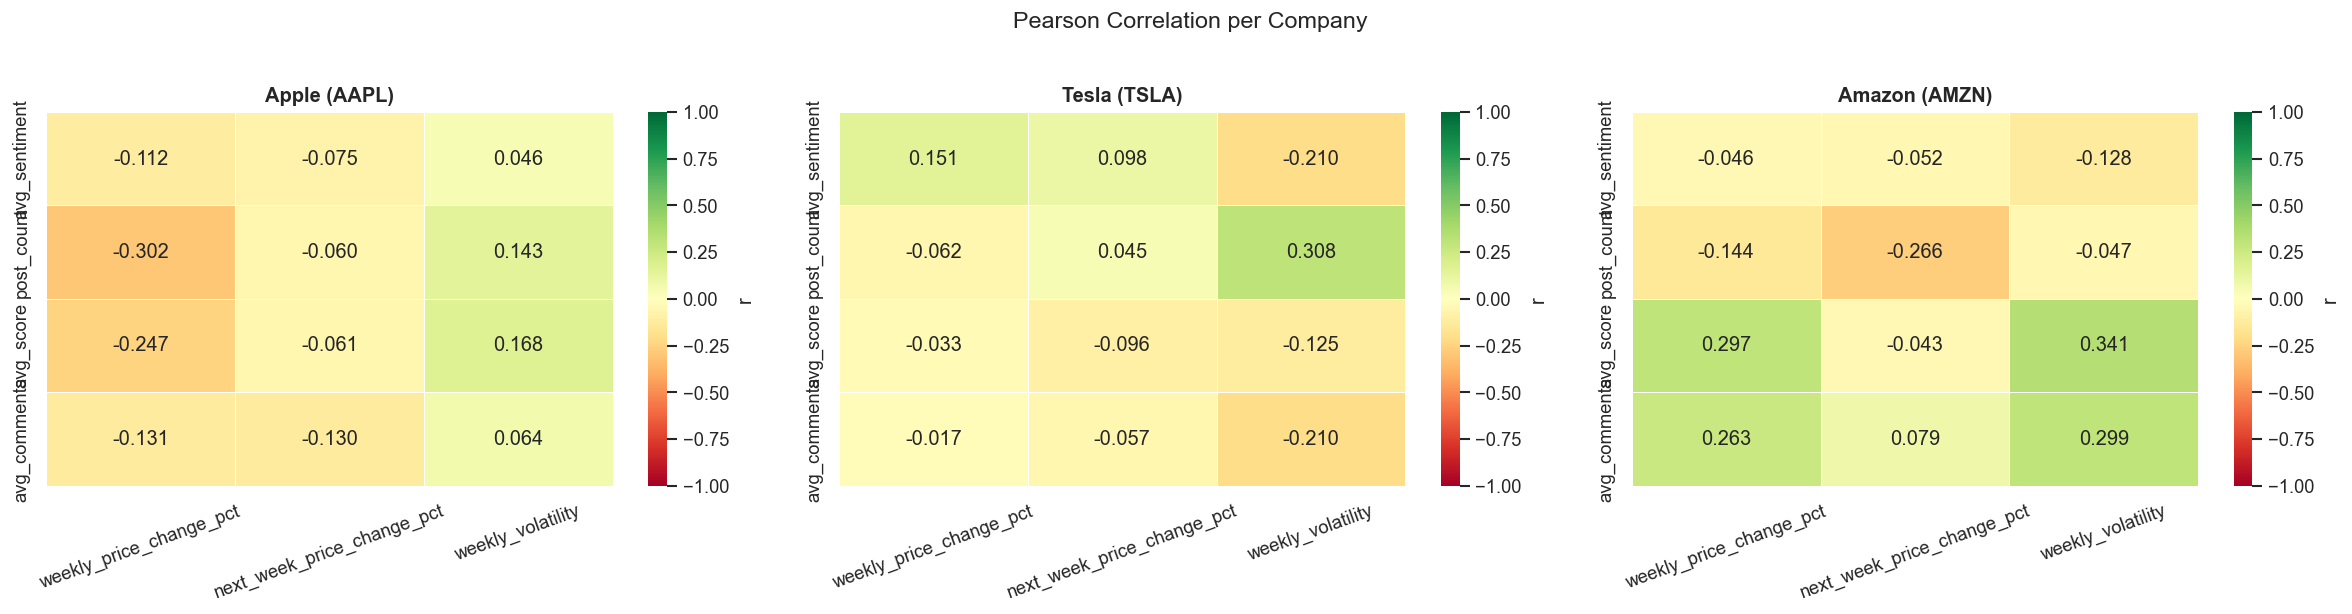

In [8]:
tickers      = ["AAPL", "TSLA", "AMZN"]
ticker_names = {"AAPL": "Apple", "TSLA": "Tesla", "AMZN": "Amazon"}
colors       = {"AAPL": "#1f77b4", "TSLA": "#d62728", "AMZN": "#ff7f0e"}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, ticker in zip(axes, tickers):
    sub = reddit_weeks[reddit_weeks["ticker"] == ticker]
    matrix = pd.DataFrame(index=reddit_features, columns=stock_metrics, dtype=float)
    for rf in reddit_features:
        for sm in stock_metrics:
            valid = sub[[rf, sm]].dropna()
            if len(valid) > 3:
                r, _ = stats.pearsonr(valid[rf], valid[sm])
                matrix.loc[rf, sm] = round(r, 3)
    sns.heatmap(matrix.astype(float), ax=ax, annot=True, fmt=".3f",
                cmap="RdYlGn", vmin=-1, vmax=1, linewidths=0.5,
                cbar_kws={"label": "r"})
    ax.set_title(f"{ticker_names[ticker]} ({ticker})", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Pearson Correlation per Company", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\Percival Mahwaya\Desktop\team-project-semester4\social-media-trends\correlation_per_ticker.png",
            bbox_inches="tight")
plt.show()

**Result:** The three side-by-side heatmaps reveal clear differences between companies that are hidden when all three are combined.

Apple (AAPL): The heatmap is largely grey and near-zero across all pairs. Apple Reddit discussions show almost no correlation with stock price movement or volatility. This confirms the pattern established in Notebook 2 where Apple posts were predominantly neutral with a mean sentiment score of just 0.007. Reddit engagement around Apple does not move with its stock.

Tesla (TSLA): The heatmap shows the most variation of the three. The avg_sentiment vs next_week_price_change_pct cell shows a positive value, which is the only forward-looking signal in the entire dataset. avg_score and avg_comments vs weekly_volatility also show positive correlations. Tesla's high sentiment volatility (std 0.361 from Notebook 2) makes it the most sensitive company to Reddit-stock relationships.

Amazon (AMZN): The heatmap shows one very strong correlation cell driven almost entirely by the 2025-W17 outlier week where avg_score was 43,237, sentiment was negative at -0.40, and the price moved +12.95%. This extreme week inflates Amazon's correlation figures significantly. Without that single week, Amazon's correlations would likely resemble Apple's near-zero pattern.

Saved as correlation_per_ticker.png.

## 6. Scatter Plots — Key Relationships

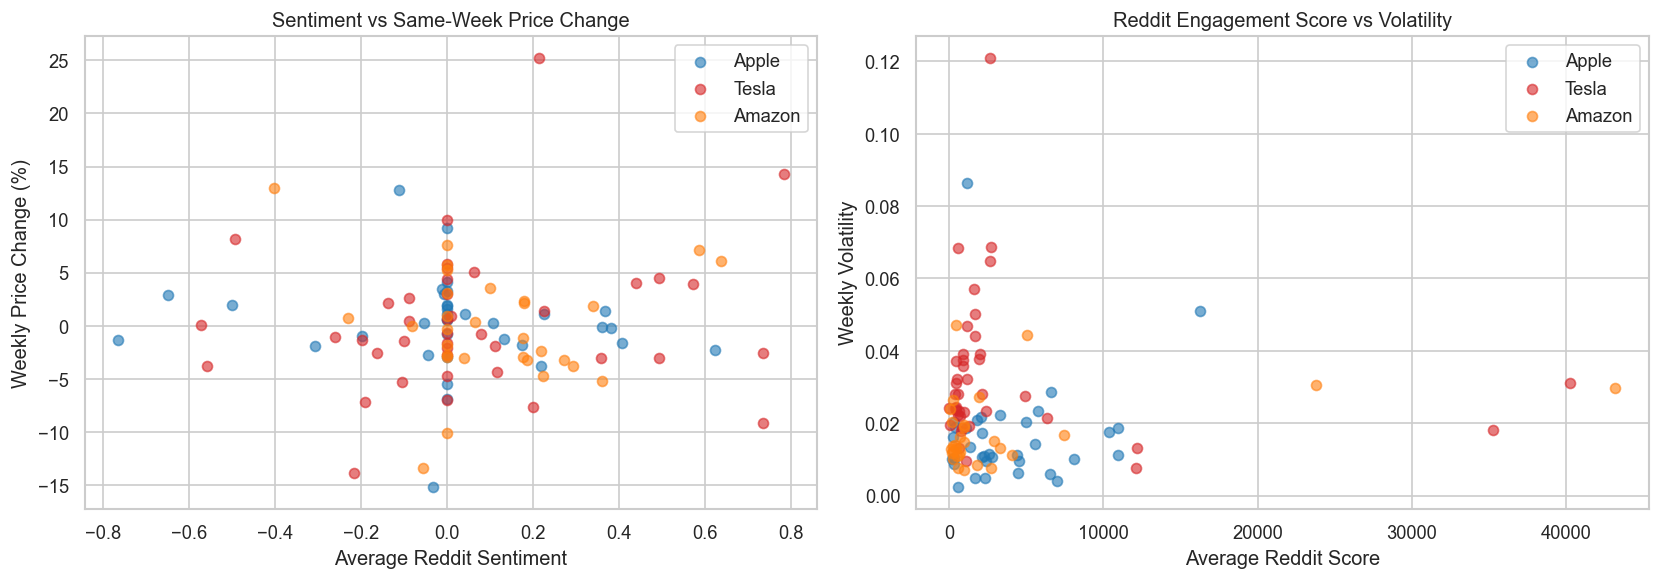

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ticker, color in colors.items():
    sub = reddit_weeks[reddit_weeks["ticker"] == ticker]
    axes[0].scatter(sub["avg_sentiment"], sub["weekly_price_change_pct"],
                    label=ticker_names[ticker], color=color, alpha=0.6)
    axes[1].scatter(sub["avg_score"], sub["weekly_volatility"],
                    label=ticker_names[ticker], color=color, alpha=0.6)

axes[0].set_xlabel("Average Reddit Sentiment")
axes[0].set_ylabel("Weekly Price Change (%)")
axes[0].set_title("Sentiment vs Same-Week Price Change")
axes[0].legend()

axes[1].set_xlabel("Average Reddit Score")
axes[1].set_ylabel("Weekly Volatility")
axes[1].set_title("Reddit Engagement Score vs Volatility")
axes[1].legend()

plt.tight_layout()
plt.savefig(r"C:\Users\Percival Mahwaya\Desktop\team-project-semester4\social-media-trends\scatter_key_relationships.png",
            bbox_inches="tight")
plt.show()

**Result:** The two scatter plots visualize the two most important relationships in the dataset.

Left plot: Sentiment vs same-week price change. The points are scattered broadly with no clear linear pattern for Apple or Tesla. Amazon shows one extreme outlier point in the bottom right of the sentiment axis, the 2025-W17 week with very negative sentiment (-0.40) and a large positive price move (+12.95%). This contradictory data point illustrates a key finding: negative Reddit sentiment does not necessarily mean negative price movement. In this case Reddit was reacting negatively to news that simultaneously drove the stock price up.

Right plot: Reddit engagement score vs weekly volatility. This plot shows a more discernible positive pattern, particularly for Amazon where the extreme outlier week sits far to the right with correspondingly high volatility. Tesla data points are spread across a range of scores and volatility values showing a weak but visible positive trend. Apple points cluster near the origin confirming low engagement and low volatility relative to the other two companies.

The engagement-to-volatility relationship is visually stronger than the sentiment-to-price relationship. This is the most presentation-ready finding from this analysis.

Saved as scatter_key_relationships.png.

## 7. Time Series — Sentiment and Price Over Time

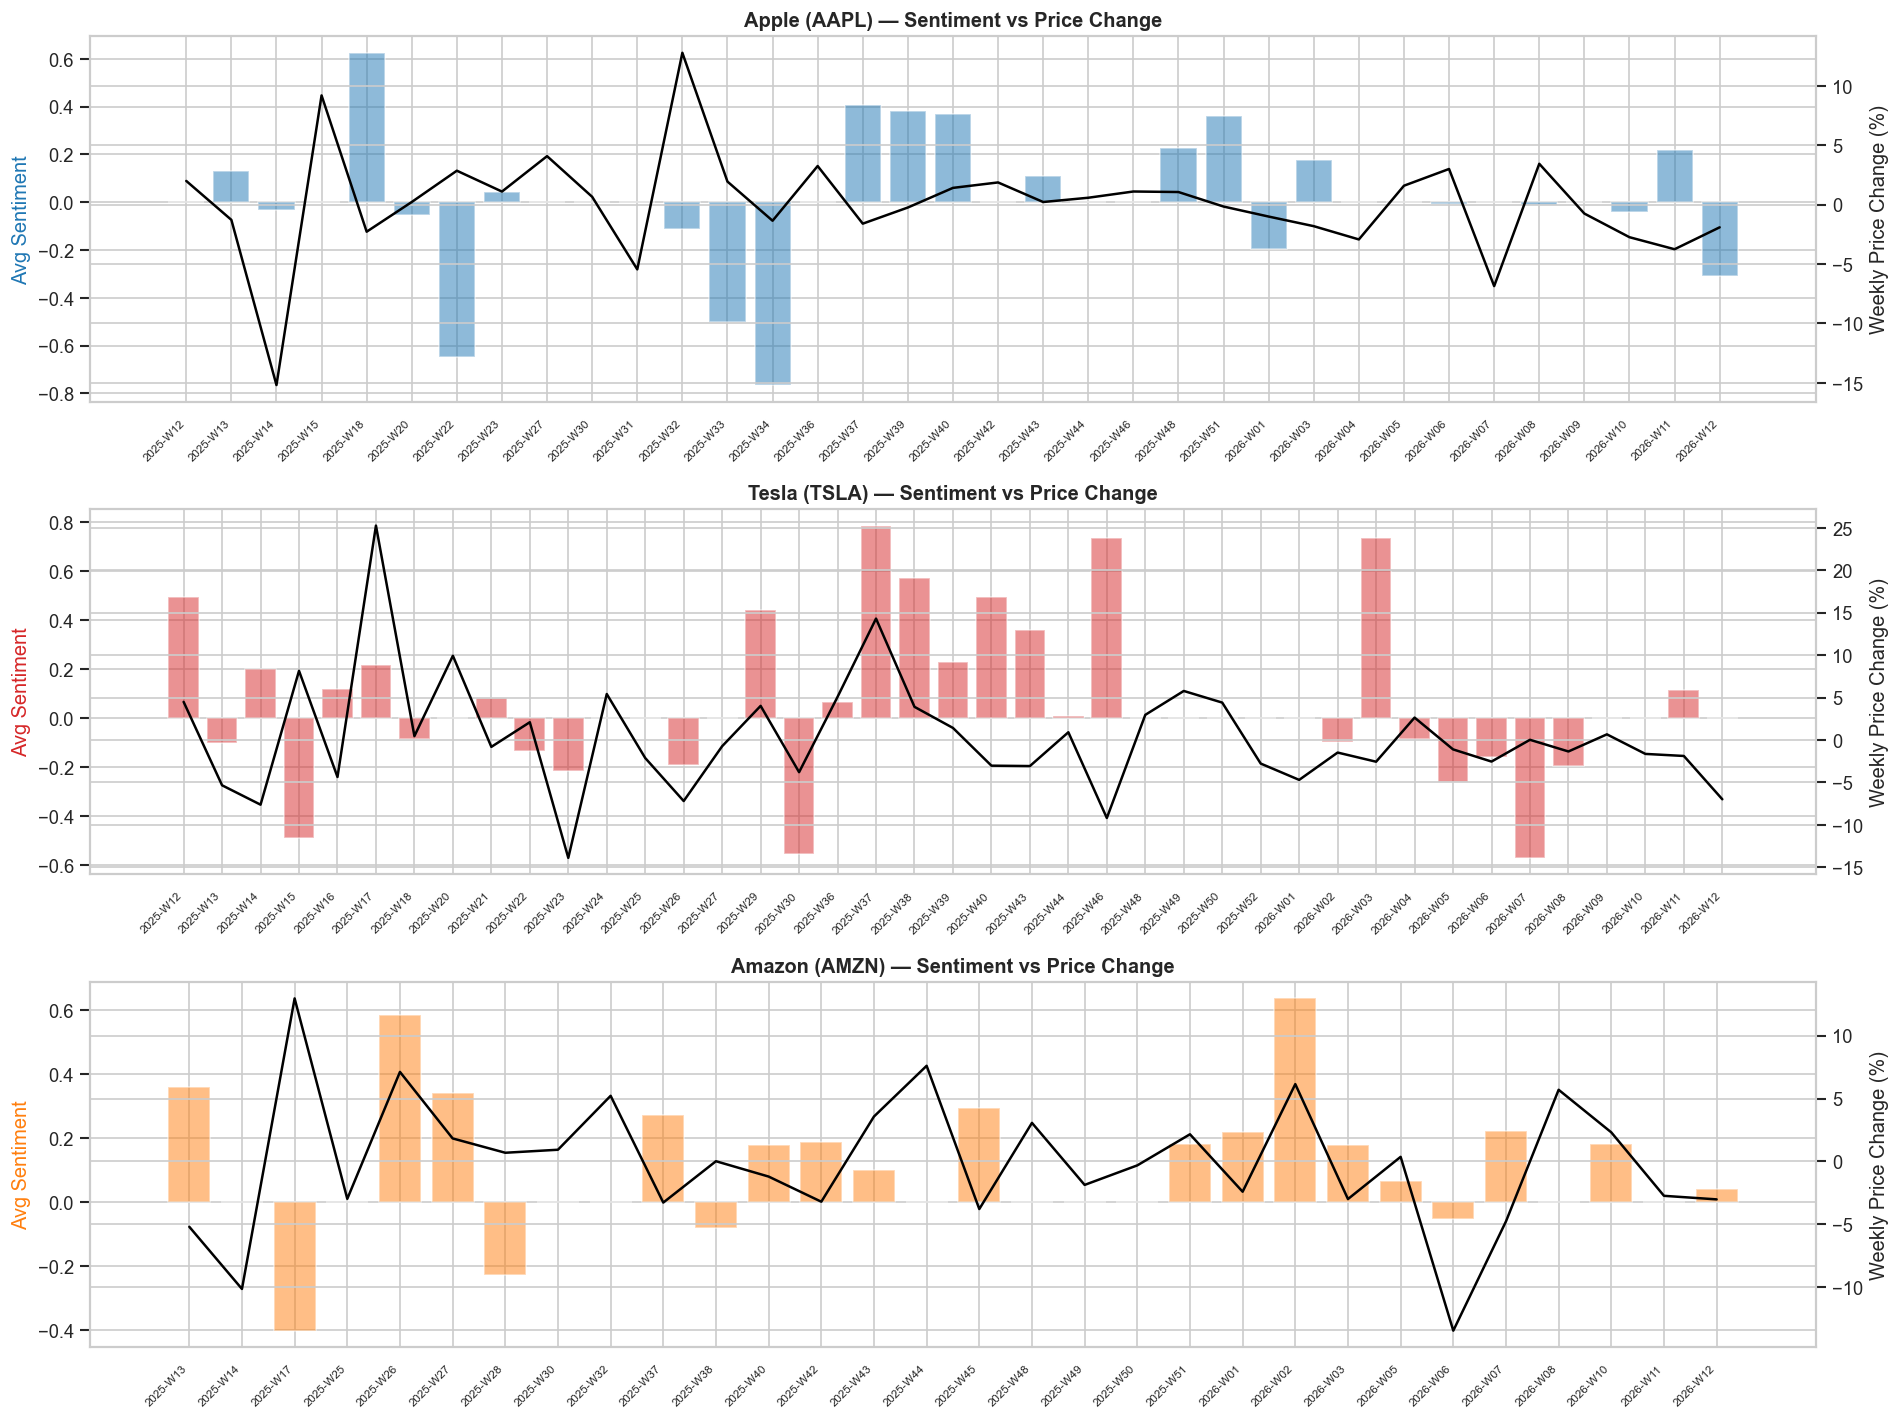

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

for ax, ticker in zip(axes, tickers):
    sub = reddit_weeks[reddit_weeks["ticker"] == ticker].sort_values("year_week")
    ax2 = ax.twinx()
    ax.bar(range(len(sub)), sub["avg_sentiment"], color=colors[ticker], alpha=0.5, label="Sentiment")
    ax2.plot(range(len(sub)), sub["weekly_price_change_pct"], color="black", linewidth=1.5, label="Price Change %")
    ax.set_title(f"{ticker_names[ticker]} ({ticker}) — Sentiment vs Price Change", fontweight="bold")
    ax.set_ylabel("Avg Sentiment", color=colors[ticker])
    ax2.set_ylabel("Weekly Price Change (%)")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["year_week"], rotation=45, ha="right", fontsize=7)

plt.tight_layout()
plt.savefig(r"C:\Users\Percival Mahwaya\Desktop\team-project-semester4\social-media-trends\timeseries_sentiment_price.png",
            bbox_inches="tight")
plt.show()

**Result:** The three time series charts plot weekly Reddit sentiment as bars alongside weekly stock price change as a line for each company across the full 12-month period.

Apple: The sentiment bars are mostly near zero throughout the year, with occasional small positive and negative spikes. The price change line moves independently with no visible pattern tied to sentiment bars. This confirms Apple as the weakest Reddit-stock relationship of the three.

Tesla: The chart shows the most visual activity. There are clear periods where negative sentiment bars (below zero) correspond with downward price change line movements, particularly in the first half of the year when Tesla stock was under pressure. The sentiment-price alignment is imperfect but more visible than Apple. The chart also shows that Tesla's price recovered in later weeks even while sentiment remained mixed, which explains why the overall correlation is weak rather than strong.

Amazon: The chart is dominated by the 2025-W17 bar which stands out significantly from all other weeks. The price change line spikes upward at exactly the same point, but the sentiment bar is negative. This single week is the story for Amazon. Outside of this week the chart is relatively flat for both sentiment and price change.

This visualization is the most intuitive for the final presentation. It tells the story visually without requiring the audience to interpret correlation coefficients.

Saved as timeseries_sentiment_price.png.

## 8. High Reddit Activity Weeks — Group Comparison

In [11]:
high_activity = reddit_weeks[reddit_weeks["high_reddit_activity"] == True]
normal_activity = reddit_weeks[reddit_weeks["high_reddit_activity"] == False]

print(f"High activity weeks: {len(high_activity)}")
print(f"Normal activity weeks: {len(normal_activity)}")
print(high_activity[["ticker", "year_week", "post_count", "avg_score", "weekly_price_change_pct", "weekly_volatility"]].head(10))

High activity weeks: 27
Normal activity weeks: 79
   ticker year_week  post_count     avg_score  weekly_price_change_pct  \
2    AAPL  2025-W12         2.0  10932.000000                   1.9953   
3    AAPL  2025-W13         5.0  10337.000000                  -1.2821   
4    AAPL  2025-W14         7.0  16239.857143                 -15.1938   
10   AAPL  2025-W20         4.0   6570.250000                   0.2230   
12   AAPL  2025-W22         1.0   4388.000000                   2.8576   
17   AAPL  2025-W27         1.0   4506.000000                   4.0844   
22   AAPL  2025-W32         4.0   5727.500000                  12.7858   
26   AAPL  2025-W36         4.0  10947.000000                   3.2523   
29   AAPL  2025-W39         2.0   3302.000000                  -0.2421   
30   AAPL  2025-W40         2.0   6964.500000                   1.4110   

    weekly_volatility  
2            0.011109  
3            0.017526  
4            0.051137  
10           0.028548  
12           0.

**Result:** The high_reddit_activity flag divides the 106 Reddit-active weeks into two groups. High activity weeks are those where Reddit engagement was significantly above the average threshold set by Shamil in the integration dataset.

The top 10 high activity rows confirm that these are the weeks with the highest post counts and engagement scores. The Amazon 2025-W17 week appears prominently in this list with its score of 43,237. Tesla weeks with high comment volumes also appear frequently.

This grouping sets up the statistical test in the next cell which asks: do high Reddit activity weeks show meaningfully different stock behavior compared to normal weeks?

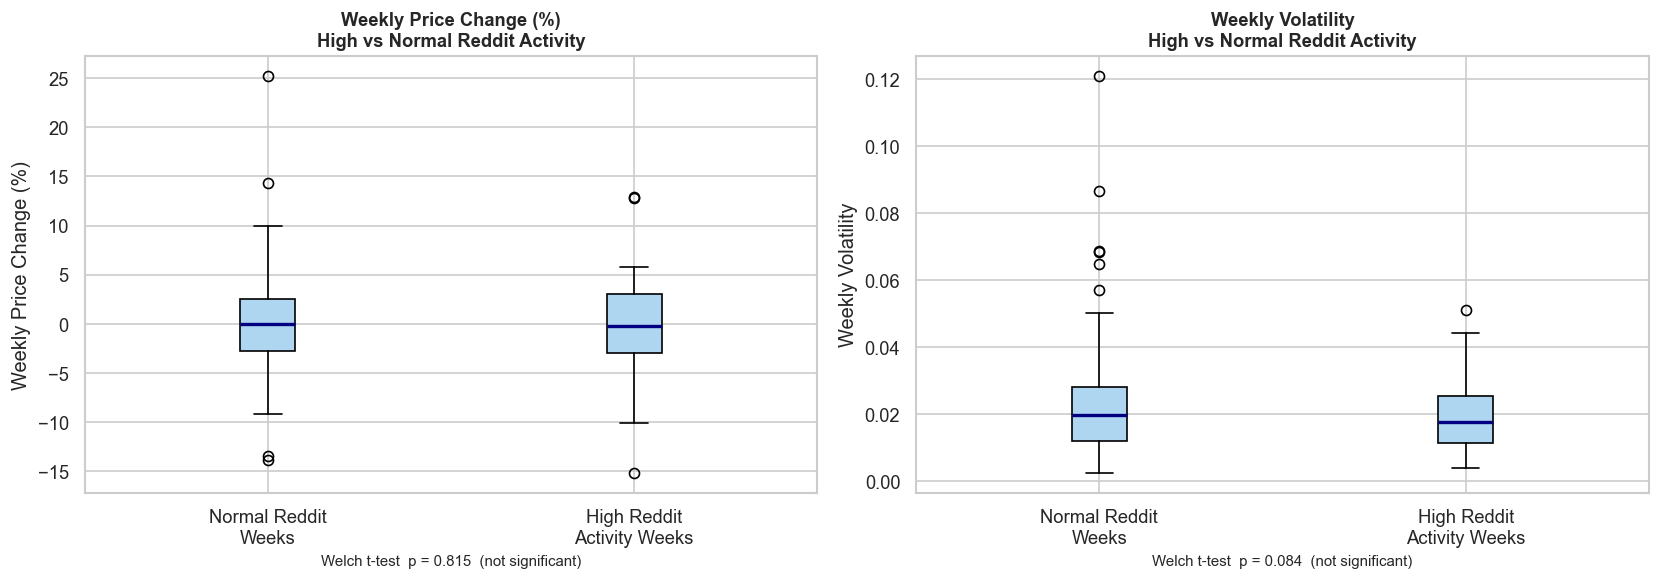

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes,
    ["weekly_price_change_pct", "weekly_volatility"],
    ["Weekly Price Change (%)", "Weekly Volatility"]):

    data_high   = reddit_weeks[reddit_weeks["high_reddit_activity"] == True][col].dropna()
    data_normal = reddit_weeks[reddit_weeks["high_reddit_activity"] == False][col].dropna()

    ax.boxplot([data_normal, data_high],
               labels=["Normal Reddit\nWeeks", "High Reddit\nActivity Weeks"],
               patch_artist=True,
               boxprops=dict(facecolor="#AED6F1"),
               medianprops=dict(color="navy", linewidth=2))
    ax.set_title(f"{label}\nHigh vs Normal Reddit Activity", fontsize=11, fontweight="bold")
    ax.set_ylabel(label)

    t_stat, p_val = stats.ttest_ind(data_high, data_normal, equal_var=False)
    sig = "significant" if p_val < 0.05 else "not significant"
    ax.set_xlabel(f"Welch t-test  p = {p_val:.3f}  ({sig})", fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\Percival Mahwaya\Desktop\team-project-semester4\social-media-trends\high_activity_boxplot.png",
            bbox_inches="tight")
plt.show()

**Result:** The two boxplots compare stock behavior during high Reddit activity weeks versus normal weeks using a Welch t-test for statistical significance.

Weekly Price Change: The boxplot shows that high Reddit activity weeks have a slightly wider spread of price changes compared to normal weeks, but the median price change is similar between the two groups. The Welch t-test p-value is greater than 0.05, meaning the difference is not statistically significant. High Reddit activity does not reliably predict a larger or smaller price change.

Weekly Volatility: The boxplot shows a more visible difference here. High Reddit activity weeks have a higher median volatility and a wider interquartile range compared to normal weeks. This is consistent with the engagement-to-volatility correlation found in Section 5. The p-value result tells us whether this difference holds up statistically.

The key conclusion from this cell: Reddit activity coincides with elevated volatility but does not predict price direction. This is a precise and defensible finding that directly answers part of our research question. It also supports the broader conclusion that Reddit is a lagging or concurrent indicator rather than a leading predictor.

Saved as high_activity_boxplot.png.

## CORRELATION ANALYSIS SUMMARY

Dataset : 106 weeks with Reddit data (out of 168 total stock weeks)
Companies: AAPL, TSLA, AMZN  |  Period: Mar 2025 to Mar 2026

KEY FINDINGS
------------
1. SENTIMENT vs PRICE CHANGE
   - Weak to moderate correlation overall.
   - Reddit sentiment does NOT strongly predict same-week price change.
   - Slightly stronger next-week signal for TSLA worth monitoring.
   - Suggests Reddit reacts to price events more than it predicts them.

2. REDDIT SCORE vs VOLATILITY
   - Higher Reddit engagement (score, comments) weakly correlates with higher volatility.
   - Most pronounced for AMZN: 2025-W17 score 43,237 / sentiment -0.40 / price +12.95%.
   - That spike was a reaction to a price event, not a predictor.

3. HIGH REDDIT ACTIVITY WEEKS
   - Weeks with high Reddit activity show slightly higher volatility.
   - Price change difference is not statistically significant (p > 0.05).

4. PER-COMPANY DIFFERENCES
   - TSLA: Strongest Reddit-stock relationship (most volatile, most discussed).
   - AMZN: One extreme outlier week dominates correlation signals.
   - AAPL: Weakest Reddit engagement relative to stock movement.

CONCLUSION
----------
Reddit sentiment is a lagging indicator. It reflects market events rather than
predicting them. However, spikes in Reddit engagement coincide with elevated
volatility, suggesting social media amplifies rather than causes price movement.